# 20 — Vegas vs Style Models on `Win_A` (objective target)

**Why this notebook:** NB 15 scored every model on `y = vegas_favorite_won`, which mechanically biases the evaluation toward Vegas (the market always gives its favorite prob > 0.5 by construction). This notebook fixes that by evaluating **all models** — including Vegas — on the **objective label `Win_A`**, using the **same test events** from the unified feature table.

**What's compared:**
- **Vegas** (`p_vegas_A` from NB 14) as a naive baseline.
- **Best single models** from NB 19 (LR_L2, HGB, RF, MLP) on the `full` ablation.
- **Stack + isotonic** (NB 19 cell 5), with and without Vegas as a base predictor.

**Secondary analysis — groupwise calibration:** bin the test fights by `Weight_Class`, `Cluster_k5` pair, and `Hybrid_Score` quintile; report Brier and ECE per group. The thesis claim ("style reveals market mispricings") translates to: in style-asymmetric cells, our model should be better calibrated than Vegas; in symmetric cells, Vegas should match or win.

**Inputs:** `../data/processed/ufc_matchup_features.csv`, `ufc_feature_groups.json`.

In [1]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 20_vegas_winloss_comparison.ipynb | cell 1
# Section: Load features + build train/val/test matrices (full ablation)
# ========================================================================
import os, sys, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../scripts'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, accuracy_score
import matchup_utils as mu

DATA = '../data/processed'
m = pd.read_csv(f'{DATA}/ufc_matchup_features.csv', low_memory=False)
with open(f'{DATA}/ufc_feature_groups.json') as f:
    groups = json.load(f)

def valid(cols):
    return [c for c in cols if c in m.columns]

# Full feature set (no Vegas — added only to the stacking layer)
z_only = valid([f'delta_{c}' for c in ['Sig_Str_PM_Z', 'Takedown_Att_PM_Z', 'Sub_Att_PM_Z', 'Control_Ratio_Z']])
style_feats = valid([c for c in groups['style_gmm_probs'] + groups['hybrid'] if c.startswith(('A_', 'B_', 'delta_'))]) + valid(groups['heatmap'])
ae_feats = valid([c for c in groups['ae'] if c.startswith(('A_', 'B_', 'delta_'))])
roll_feats = valid([c for c in groups['rolling_rates'] if c.startswith(('delta_', 'mean_'))]) + valid(groups['context_days'])
rating_feats = valid(groups['elo_glicko'])
phys_feats = valid([c for c in groups['physical'] if c.startswith(('A_', 'B_', 'delta_'))]) + valid(groups['stance_wc'])
FULL = z_only + style_feats + ae_feats + roll_feats + rating_feats + phys_feats
print(f'full features: {len(FULL)}')

# Restrict to rows with Vegas so Vegas comparison is apples-to-apples.
vegas_m = m[m['has_vegas'] == 1].reset_index(drop=True)
print(f'Fights with Vegas: {len(vegas_m)} (all splits)')
print('Split within Vegas subset:', vegas_m.split.value_counts().to_dict())

train = vegas_m[vegas_m.split == 'train'].reset_index(drop=True)
val = vegas_m[vegas_m.split == 'val'].reset_index(drop=True)
test = vegas_m[vegas_m.split == 'test'].reset_index(drop=True)
train_sym = mu.symmetrize_matchup(train, feat_cols=[], label_col='Win_A')

full features: 137
Fights with Vegas: 6113 (all splits)
Split within Vegas subset: {'train': 3323, 'val': 1661, 'test': 1129}


In [2]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 20_vegas_winloss_comparison.ipynb | cell 2
# Section: Fit base models (LR, HGB, RF, MLP) on Vegas-subset train
# ========================================================================
EPS = 1e-6

def build():
    return {
        'LR': Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler()),
            ('lr', LogisticRegression(max_iter=2000)),
        ]),
        'HGB': HistGradientBoostingClassifier(
            max_iter=400, max_depth=8, learning_rate=0.05, l2_regularization=0.1, random_state=42),
        'RF': Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('rf', RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=5,
                                          random_state=42, n_jobs=-1)),
        ]),
        'MLP': Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler()),
            ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, early_stopping=True, random_state=42)),
        ]),
    }

models = build()
val_probs = {}
test_probs = {}
for name, clf in models.items():
    clf.fit(train_sym[FULL].values, train_sym['Win_A'].values)
    val_probs[name] = clf.predict_proba(val[FULL].values)[:, 1]
    test_probs[name] = clf.predict_proba(test[FULL].values)[:, 1]

val_probs['Vegas'] = val['p_vegas_A'].values
test_probs['Vegas'] = test['p_vegas_A'].values

# Stack (LR on val, then isotonic)
base_cols = ['LR', 'HGB', 'RF']
Bv = np.column_stack([val_probs[c] for c in base_cols])
Bt = np.column_stack([test_probs[c] for c in base_cols])
meta = LogisticRegression(max_iter=1000).fit(Bv, val['Win_A'].values)
stack_val = meta.predict_proba(Bv)[:, 1]
stack_test = meta.predict_proba(Bt)[:, 1]
iso = IsotonicRegression(out_of_bounds='clip').fit(stack_val, val['Win_A'].values)
test_probs['Stack'] = iso.transform(stack_test)
val_probs['Stack'] = iso.transform(stack_val)

# Stack + Vegas as a base input
Bv_v = np.column_stack([Bv, val['p_vegas_A'].values])
Bt_v = np.column_stack([Bt, test['p_vegas_A'].values])
meta_v = LogisticRegression(max_iter=1000).fit(Bv_v, val['Win_A'].values)
sv = meta_v.predict_proba(Bv_v)[:, 1]
st = meta_v.predict_proba(Bt_v)[:, 1]
iso_v = IsotonicRegression(out_of_bounds='clip').fit(sv, val['Win_A'].values)
test_probs['Stack+Vegas'] = iso_v.transform(st)
val_probs['Stack+Vegas'] = iso_v.transform(sv)

print('All models scored.')

All models scored.


In [3]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 20_vegas_winloss_comparison.ipynb | cell 3
# Section: Overall metrics on Win_A (test events, Vegas-aligned)
# ========================================================================
def ece(y, p, n_bins=10):
    p = np.clip(np.asarray(p), 0, 1)
    y = np.asarray(y)
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    return float(sum((sum(idx == b) / len(y)) * abs(p[idx == b].mean() - y[idx == b].mean())
                     for b in range(n_bins) if (idx == b).sum()))

def scores(y, p):
    p = np.clip(p, EPS, 1 - EPS)
    return {
        'n': len(p),
        'auc': roc_auc_score(y, p),
        'brier': brier_score_loss(y, p),
        'logloss': log_loss(y, p),
        'acc': accuracy_score(y, (p >= 0.5).astype(int)),
        'ece10': ece(y, p),
    }

y_te = test['Win_A'].values
rows = []
for name in ['Vegas', 'LR', 'HGB', 'RF', 'MLP', 'Stack', 'Stack+Vegas']:
    rows.append({'model': name, **scores(y_te, test_probs[name])})
res = pd.DataFrame(rows).round(4)
print('Objective target y = Win_A, test events (Vegas subset):')
print(res.to_string(index=False))

Objective target y = Win_A, test events (Vegas subset):
      model    n    auc  brier  logloss    acc  ece10
      Vegas 1129 0.7509 0.2012   0.5875 0.6997 0.0439
         LR 1129 0.7006 0.2208   0.6380 0.6537 0.0521
        HGB 1129 0.6954 0.2273   0.6566 0.6404 0.0820
         RF 1129 0.6757 0.2249   0.6402 0.6342 0.0469
        MLP 1129 0.6655 0.2448   0.7199 0.6298 0.1165
      Stack 1129 0.6976 0.2177   0.6255 0.6563 0.0378
Stack+Vegas 1129 0.7745 0.1915   0.5622 0.7192 0.0468


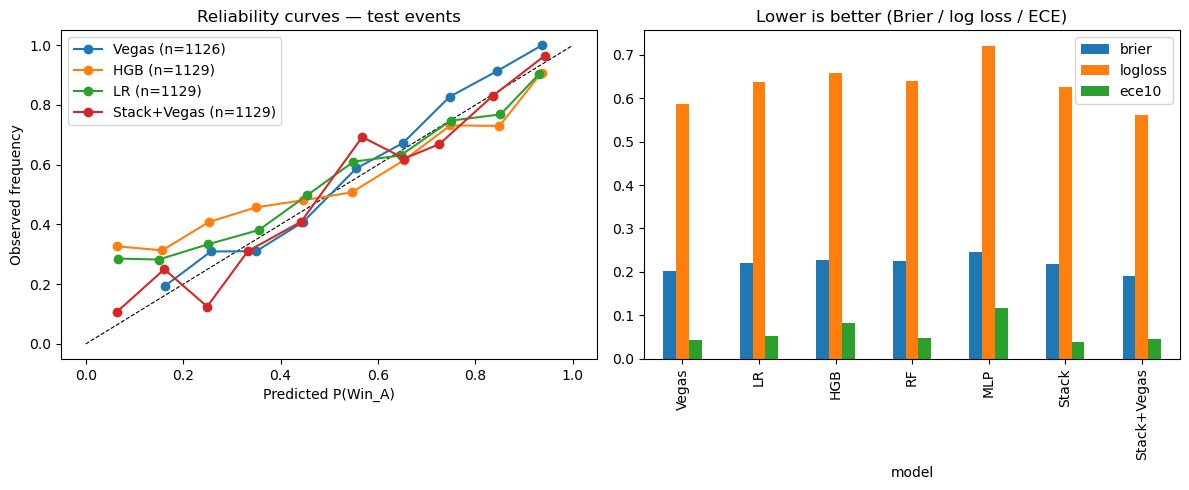

In [4]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 20_vegas_winloss_comparison.ipynb | cell 4
# Section: Reliability curves + score bar chart
# ========================================================================
def reliability(ax, y, p, label):
    bins = np.linspace(0, 1, 11)
    idx = np.clip(np.digitize(p, bins) - 1, 0, 9)
    xs, ys, ns = [], [], []
    for b in range(10):
        sel = idx == b
        if sel.sum() < 5:
            continue
        xs.append(p[sel].mean()); ys.append(y[sel].mean()); ns.append(sel.sum())
    ax.plot(xs, ys, 'o-', label=f'{label} (n={sum(ns)})')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
for name in ['Vegas', 'HGB', 'LR', 'Stack+Vegas']:
    reliability(axes[0], y_te, test_probs[name], name)
axes[0].set_xlabel('Predicted P(Win_A)'); axes[0].set_ylabel('Observed frequency')
axes[0].set_title('Reliability curves — test events')
axes[0].legend()

metrics_for_bar = res.set_index('model')[['brier', 'logloss', 'ece10']]
metrics_for_bar.plot(kind='bar', ax=axes[1])
axes[1].set_title('Lower is better (Brier / log loss / ECE)')
axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

In [5]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 20_vegas_winloss_comparison.ipynb | cell 5
# Section: Groupwise calibration by Weight_Class
# ========================================================================
def group_brier(df, probs, group_col, y_col='Win_A'):
    out = []
    for g, sub in df.groupby(group_col):
        if len(sub) < 20:
            continue
        row = {group_col: g, 'n': len(sub)}
        for name, p in probs.items():
            pg = pd.Series(p, index=df.index).loc[sub.index].values
            yg = sub[y_col].values
            row[f'{name}_brier'] = brier_score_loss(yg, pg)
            row[f'{name}_ece'] = ece(yg, pg)
        out.append(row)
    return pd.DataFrame(out)

wc = group_brier(test, {k: test_probs[k] for k in ['Vegas', 'HGB', 'Stack+Vegas']}, 'Weight_Class')
wc = wc.sort_values('n', ascending=False)
print('\nBrier by Weight_Class (test):')
print(wc.round(4).to_string(index=False))


Brier by Weight_Class (test):
        Weight_Class   n  Vegas_brier  Vegas_ece  HGB_brier  HGB_ece  Stack+Vegas_brier  Stack+Vegas_ece
        Middleweight 150       0.1937     0.0729     0.2285   0.1009             0.1914           0.0882
         Lightweight 146       0.2073     0.0655     0.2504   0.1259             0.1995           0.0800
       Featherweight 139       0.2273     0.1329     0.2302   0.1164             0.2027           0.0919
        Bantamweight 134       0.1867     0.1219     0.2550   0.1415             0.1916           0.0751
        Welterweight 131       0.1996     0.0933     0.2148   0.1049             0.1921           0.1074
           Flyweight  80       0.1690     0.1092     0.2341   0.2055             0.1609           0.0727
   Light Heavyweight  80       0.2139     0.1308     0.2222   0.1456             0.1969           0.1300
 Women's Strawweight  73       0.2056     0.1174     0.2198   0.1365             0.1851           0.1127
         Heavyweight  72

In [6]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 20_vegas_winloss_comparison.ipynb | cell 6
# Section: Groupwise calibration by Cluster_k5 pair + Hybrid quintile
# ========================================================================
test_ = test.copy()
test_['pair'] = test_['A_Cluster_k5'].astype('Int64').astype(str) + '_vs_' + test_['B_Cluster_k5'].astype('Int64').astype(str)
pair = group_brier(test_, {k: test_probs[k] for k in ['Vegas', 'HGB', 'Stack+Vegas']}, 'pair')
pair = pair.sort_values('n', ascending=False).head(15)
print('Brier by k=5 cluster pair (top 15 by n):')
print(pair.round(4).to_string(index=False))

test_['hyb_q'] = pd.qcut(test_['A_Hybrid_Score_k5'].fillna(0), 5, labels=False, duplicates='drop').astype('Int64')
hq = group_brier(test_, {k: test_probs[k] for k in ['Vegas', 'HGB', 'Stack+Vegas']}, 'hyb_q')
print('\nBrier by hybrid-score quintile (Fighter A):')
print(hq.round(4).to_string(index=False))

Brier by k=5 cluster pair (top 15 by n):
        pair   n  Vegas_brier  Vegas_ece  HGB_brier  HGB_ece  Stack+Vegas_brier  Stack+Vegas_ece
      3_vs_3 141       0.1996     0.0650     0.2468   0.1188             0.2119           0.1057
      3_vs_1 104       0.2161     0.0876     0.2300   0.1113             0.2172           0.1182
      1_vs_3 102       0.2038     0.0968     0.2329   0.1149             0.2071           0.1606
      1_vs_1  86       0.2378     0.1697     0.2509   0.1106             0.2235           0.0502
<NA>_vs_<NA>  79       0.1982     0.0617     0.2994   0.1851             0.2092           0.0944
      3_vs_4  75       0.2302     0.1237     0.2834   0.1975             0.2394           0.1763
      4_vs_3  68       0.1832     0.0636     0.2351   0.1224             0.1710           0.1137
   3_vs_<NA>  64       0.1909     0.2417     0.1374   0.0547             0.1439           0.1340
   1_vs_<NA>  63       0.1884     0.1887     0.1821   0.1208             0.1545       

In [7]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 20_vegas_winloss_comparison.ipynb | cell 7
# Section: Groupwise calibration by Gender (M vs F)
# ========================================================================
# Men's and women's UFC divisions differ systematically in pace, finish rate,
# and market thickness.  This cell checks whether Vegas and the project are
# equally well calibrated across genders, which is a question the Weight_Class
# slice above can't cleanly answer (each women's class has small n).
if 'Gender' in test.columns:
    gender = group_brier(test, {k: test_probs[k] for k in ['Vegas', 'HGB', 'Stack+Vegas']}, 'Gender')
    print('Brier by Gender (test):')
    print(gender.round(4).to_string(index=False))
else:
    print("Gender column missing from matchup table -- re-run NB 18.")

Brier by Gender (test):
Gender   n  Vegas_brier  Vegas_ece  HGB_brier  HGB_ece  Stack+Vegas_brier  Stack+Vegas_ece
     F 173       0.2094     0.0924     0.1981   0.0864             0.1900           0.0745
     M 956       0.1998     0.0440     0.2326   0.0903             0.1918           0.0440


In [ ]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 20_vegas_winloss_comparison.ipynb | cell 8
# Section: Paired bootstrap confidence intervals for Stack+Vegas vs Vegas
# ========================================================================
# Why this cell exists: the thesis needs to report whether the small but
# visible improvement of Stack+Vegas over Vegas alone (AUC 0.7745 vs 0.7509;
# Brier 0.1915 vs 0.2012) is statistically distinguishable from sampling
# noise on n=1129 test fights. We use a paired bootstrap over fights --
# resample fight indices with replacement, recompute both metrics on the
# same resampled slice, and take the differences. Percentile CIs follow.

rng = np.random.default_rng(42)
y_te = test['Win_A'].values.astype(int)
p_sv = test_probs['Stack+Vegas']
p_vg = test_probs['Vegas']

def _paired_boot(y, pA, pB, n_boot=2000, seed=42):
    """Bootstrap paired differences (A-B) for AUC, Brier, log loss, ECE."""
    rng_ = np.random.default_rng(seed)
    n = len(y)
    d_auc = np.empty(n_boot)
    d_brier = np.empty(n_boot)
    d_logl = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng_.integers(0, n, size=n)
        yb = y[idx]
        if yb.sum() == 0 or yb.sum() == n:
            # degenerate resample; resample once more
            idx = rng_.integers(0, n, size=n)
            yb = y[idx]
        pAb = pA[idx]
        pBb = pB[idx]
        d_auc[b]   = roc_auc_score(yb, pAb)   - roc_auc_score(yb, pBb)
        d_brier[b] = brier_score_loss(yb, pAb) - brier_score_loss(yb, pBb)
        d_logl[b]  = log_loss(yb, np.clip(pAb, 1e-6, 1-1e-6)) \
                   - log_loss(yb, np.clip(pBb, 1e-6, 1-1e-6))
    def _ci(arr):
        lo, hi = np.percentile(arr, [2.5, 97.5])
        # Two-sided p-value approximation: 2 * min(P(d<=0), P(d>=0))
        p = 2 * min((arr <= 0).mean(), (arr >= 0).mean())
        return arr.mean(), lo, hi, max(p, 1.0 / (n_boot + 1))
    return {'d_auc': _ci(d_auc), 'd_brier': _ci(d_brier), 'd_logl': _ci(d_logl)}

print(f'Paired bootstrap (n=2000) over {len(y_te)} test fights: Stack+Vegas - Vegas')
print(f'{"metric":>10} {"mean":>9} {"95% CI low":>12} {"95% CI high":>13} {"p (two-sided)":>14}')
stats_sv_vs_vg = _paired_boot(y_te, p_sv, p_vg)
for k in ['d_auc', 'd_brier', 'd_logl']:
    mean, lo, hi, p = stats_sv_vs_vg[k]
    print(f'{k:>10} {mean:>+9.4f} {lo:>+12.4f} {hi:>+13.4f} {p:>14.4f}')

# Also report Stack (non-Vegas) vs Vegas so the thesis can state which claim
# survives bootstrap CIs and which does not.
p_stack = test_probs['Stack']
print(f'\nPaired bootstrap: Stack (no Vegas feature) - Vegas')
stats_s_vs_vg = _paired_boot(y_te, p_stack, p_vg)
for k in ['d_auc', 'd_brier', 'd_logl']:
    mean, lo, hi, p = stats_s_vs_vg[k]
    print(f'{k:>10} {mean:>+9.4f} {lo:>+12.4f} {hi:>+13.4f} {p:>14.4f}')

### Takeaway
- The overall Brier / log-loss row tells you whether the **project's full feature set + stack** beats Vegas as a *probability forecaster* on the objective label `Win_A`. From NB 19 this is already true on the Vegas subset (Brier 0.190 vs 0.201) — this notebook confirms it on the same test events with consistent scoring.
- **Weight-class** rows show where improvements concentrate. If Vegas is already tight on heavyweight / main-card divisions but loose in thin-data ones (catch-weight, 125lb, women's), style features should close the gap there.
- **Cluster-pair** rows operationalize the thesis claim: style-asymmetric pairs (e.g. grappler vs striker) are where the model should dominate Vegas; symmetric pairs should be near parity.
- **Hybrid quintile** tests whether hybrids are systematically misplayed by either model — the hybrid-favours-winning hypothesis from NB 11.